# Unilateral LSTM Model over out timeseries data


In [31]:
import os
# Make sure XLA is OFF (Metal doesn't support XLA/JIT)
# os.environ.pop("TF_XLA_FLAGS", None)
# os.environ.pop("XLA_FLAGS", None)
# os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"


import tensorflow as tf
# tf.config.optimizer.set_jit(False)
print("GPUs:", tf.config.list_physical_devices("GPU"))


import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    average_precision_score,
    PrecisionRecallDisplay,
    accuracy_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score
)

import kineticstoolkit as ktk

import random
import pickle
import json
from typing import Tuple

from tensorflow import keras
import keras_tuner as kt
from tensorflow.keras import layers as L, models as M, Input, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.losses import BinaryCrossentropy

from core.matlab_data_loader import MatlabDataLoader
from core.processing import preprocess_features
from core.timeseries import plot_compare_features, plot_all_features_overlay, bilateral_to_unilateral, split_unilateral
from core.evaluation import model_test_summary, UnilateralPredictor, pick_threshold
from core.tunning import MetaHyperModel, ModelLoader, summarize_best_N_models


from pathlib import Path
import core.constants as c

RANDOM_STATE = 42
RANDOM_STATE_2 = 6
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Optimization for M4
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Notebook configuration

- **SAVE_MODEL**  
  - `True`: Will run and save this iteration of the model.  
  - `False`: Will load the model from the results folder.

- **SAVE_DATA**  
  - `True`: Will save the train, test, and validation sets as npz files.  
  - `False`: Will load the data from the results folder.

- **USE_TENSORBOARD**  
  - `True`: Will use TensorBoard to visualize the training process.
  - `False`: Will not use TensorBoard.

- **MODEL_NAME**  
  - The name of the model.

- **MODEL_RESULTS_FOLDER**  
  - The folder where the model results will be saved.

In [32]:
MODEL_NAME = "unilateral_bilstm_inverted_v4_final"
MODEL_RESULTS_FOLDER = Path(c.RICKD_MODELS_FOLDER)/ "deep_learning" / MODEL_NAME
MODEL_RESULTS_FOLDER.mkdir(parents=True, exist_ok=True)
print(f"Model results folder: {MODEL_RESULTS_FOLDER}")

Model results folder: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/unilateral_bilstm_inverted_v4_final


In [33]:
SAVE_MODEL = False
SAVE_DATA = False
USE_TENSORBOARD = False

print(f"SAVE_MODEL: {SAVE_MODEL}")
print(f"SAVE_DATA: {SAVE_DATA}")
print(f"USE_TENSORBOARD: {USE_TENSORBOARD}")

SAVE_MODEL: False
SAVE_DATA: False
USE_TENSORBOARD: False


## Load Input Data

In [34]:
timeseries_folder = Path(c.RICKD_PROCESSED_DATA_FOLDER) / 'timeseries'

all_sessions_matrix = np.load(timeseries_folder / 'timeseries_mean_matrix.npy')
with open(timeseries_folder / 'timeseries_mean_channels.json', 'r') as f:
    channels = json.load(f)
with open(timeseries_folder / 'timeseries_mean_sessions.json', 'r') as f:
    valid_session_ids = json.load(f)

# Edge case for subject created during DQ:
valid_session_ids = [
    '300375_20140502T074159' if sid == '200375_20140502T074159' else sid
    for sid in valid_session_ids
]

print("Shape of the timeseries matrix: ", all_sessions_matrix.shape)
print("Number of channels: ", len(channels))
print("Number of sessions: ", len(valid_session_ids))

for channel in channels:
    print(channel)

Shape of the timeseries matrix:  (1813, 101, 60)
Number of channels:  60
Number of sessions:  1813
L_ankle_angle_X
L_ankle_angle_Y
L_ankle_angle_Z
L_ankle_velocity_X
L_ankle_velocity_Y
L_ankle_velocity_Z
L_foot_angle_X
L_foot_angle_Y
L_foot_angle_Z
L_foot_velocity_X
L_foot_velocity_Y
L_foot_velocity_Z
L_hip_angle_X
L_hip_angle_Y
L_hip_angle_Z
L_hip_velocity_X
L_hip_velocity_Y
L_hip_velocity_Z
L_knee_angle_X
L_knee_angle_Y
L_knee_angle_Z
L_knee_velocity_X
L_knee_velocity_Y
L_knee_velocity_Z
R_ankle_angle_X
R_ankle_angle_Y
R_ankle_angle_Z
R_ankle_velocity_X
R_ankle_velocity_Y
R_ankle_velocity_Z
R_foot_angle_X
R_foot_angle_Y
R_foot_angle_Z
R_foot_velocity_X
R_foot_velocity_Y
R_foot_velocity_Z
R_hip_angle_X
R_hip_angle_Y
R_hip_angle_Z
R_hip_velocity_X
R_hip_velocity_Y
R_hip_velocity_Z
R_knee_angle_X
R_knee_angle_Y
R_knee_angle_Z
R_knee_velocity_X
R_knee_velocity_Y
R_knee_velocity_Z
L_pelvis_angle_X
L_pelvis_angle_Y
L_pelvis_angle_Z
L_pelvis_velocity_X
L_pelvis_velocity_Y
L_pelvis_velocity_

In [35]:
print("Applying channel inversion")
print("="*50)

channels_to_invert = [
    "L_foot_angle_X",
    "L_foot_velocity_X",
    "L_ankle_angle_X", "L_ankle_angle_Y",
    "L_ankle_velocity_X", "L_ankle_velocity_Y",
    "L_knee_angle_X", "L_knee_angle_Y",
    "L_knee_velocity_X", "L_knee_velocity_Y",
    "L_hip_angle_X", "L_hip_angle_Y",
    "L_hip_velocity_X", "L_hip_velocity_Y",
    # "L_pelvis_angle_X", "L_pelvis_angle_Y",
    # "L_pelvis_velocity_X", "L_pelvis_velocity_Y",
]

# Create a copy of the original matrix to avoid modifying the original data
all_sessions_matrix_inverted = all_sessions_matrix.copy()

# Find indices of channels to invert
channels_to_invert_indices = []
for channel_name in channels_to_invert:
    if channel_name in channels:
        idx = channels.index(channel_name)
        channels_to_invert_indices.append(idx)
        print(f"Will invert channel '{channel_name}' at index {idx}")
    else:
        print(f"Warning: Channel '{channel_name}' not found in channels list")

print(f"\nInverting {len(channels_to_invert_indices)} channels...")

for channel_idx in channels_to_invert_indices:
    all_sessions_matrix_inverted[:, :, channel_idx] *= -1
    all_sessions_matrix_inverted = all_sessions_matrix_inverted.astype(np.float32)  # Ccompatibility with TF
    print(f"  Inverted channel {channels[channel_idx]} (index {channel_idx})")

print("Channel inversion completed!")

# Verify the inversion by showing some statistics
print("\nVerification of inversion:")
for i, channel_idx in enumerate(channels_to_invert_indices[:3]):  # Show first 3 for brevity
    original_mean = all_sessions_matrix[:, :, channel_idx].mean()
    inverted_mean = all_sessions_matrix_inverted[:, :, channel_idx].mean()
    print(f"  {channels[channel_idx]}: Original mean = {original_mean:.3f}, Inverted mean = {inverted_mean:.3f}")


# Delete to make sure I do not use it by mistake
del all_sessions_matrix 

Applying channel inversion
Will invert channel 'L_foot_angle_X' at index 6
Will invert channel 'L_foot_velocity_X' at index 9
Will invert channel 'L_ankle_angle_X' at index 0
Will invert channel 'L_ankle_angle_Y' at index 1
Will invert channel 'L_ankle_velocity_X' at index 3
Will invert channel 'L_ankle_velocity_Y' at index 4
Will invert channel 'L_knee_angle_X' at index 18
Will invert channel 'L_knee_angle_Y' at index 19
Will invert channel 'L_knee_velocity_X' at index 21
Will invert channel 'L_knee_velocity_Y' at index 22
Will invert channel 'L_hip_angle_X' at index 12
Will invert channel 'L_hip_angle_Y' at index 13
Will invert channel 'L_hip_velocity_X' at index 15
Will invert channel 'L_hip_velocity_Y' at index 16

Inverting 14 channels...
  Inverted channel L_foot_angle_X (index 6)
  Inverted channel L_foot_velocity_X (index 9)
  Inverted channel L_ankle_angle_X (index 0)
  Inverted channel L_ankle_angle_Y (index 1)
  Inverted channel L_ankle_velocity_X (index 3)
  Inverted channe

In [36]:
loader = MatlabDataLoader()

session_data = loader.get_session_data_full_cleaned().set_index("id")
metadata_columns = ["is_injured", "sub_id"]
# Filter session_data to only include valid_session_ids and preserve their order
session_data = session_data.loc[session_data.index.intersection(valid_session_ids)]
session_data = session_data.reindex(valid_session_ids)
session_data

,sub_id,datestring,filename,speed_r,age,Height,Weight,Gender,DominantLeg,Activities,...,injury_desc,injury2_desc,injury_name,injury2_name,injured_joint_code,injured_joint2_code,injured_side_code,injured_side2_code,has_no_injury,is_injured
id,,,,,,,,,,,,,,,,,,,,,
100001_20110531T161051,100001,2011-05-31 16:10:51,20110531t161051.json,2.489233,47.0,172.0,61.9,female,left,running,...,Inflammation or irritation of Achilles tendon ...,No injury has been diagnosed.,achilles tendonitis,no injury,ankle,no_injury,left,right,False,True
100004_20110203T120721,100004,NaN,20110203t120721.json,2.688014,35.0,175.6,59.0,male,left,running,...,Overstretching or tearing of the calf muscle f...,No injury has been diagnosed.,calf muscle strain,no injury,lower_leg,no_injury,right,right,False,True
100002_20110601T140505,100002,2011-06-01 14:05:05,20110601t140505.json,2.722687,37.0,173.4,70.6,male,left,"running, cycling, weights",...,Painful friction of iliotibial band rubbing ov...,No injury has been diagnosed.,itb syndrome,no injury,thigh,no_injury,right,right,False,True
100003_20110601T095930,100003,2011-06-01 09:59:30,20110601t095930.json,2.949904,51.0,186.0,86.5,male,right,"running, weights, cycling",...,Pain around kneecap caused by poor tracking an...,General sensation of discomfort without speci...,patellofemoral pain syndrome,pain,knee,foot,left,left,False,True
100007_20110209T135403,100007,NaN,20110209t135403.json,2.271026,35.0,162.0,84.0,female,right,running,...,General sensation of discomfort without speci...,Pain due to misalignment or excessive strain a...,pain,si joint pain,lower_leg,sacro_joint,bilateral,right,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201090_20150402T171016,201090,2015-04-02 17:10:16,20150402t171016.json,3.014297,46.0,154.0,52.0,female,right,"half marathon -, gt, marathon",...,Painful friction of iliotibial band rubbing ov...,Involuntary muscle contraction due to fatigue ...,itb syndrome,muscle spasm,thigh,hip_pelvis,bilateral,bilateral,False,True
201090_20150402T171510,201090,2015-04-02 17:15:10,20150402t171510.json,3.427074,46.0,154.0,52.0,female,right,"half marathon -, gt, marathon",...,Painful friction of iliotibial band rubbing ov...,Involuntary muscle contraction due to fatigue ...,itb syndrome,muscle spasm,thigh,hip_pelvis,bilateral,bilateral,False,True
201101_20150413T143152,201101,2015-04-13 14:31:52,20150413t143152.json,2.828602,21.0,162.0,65.5,male,right,NaN,...,No injury has been diagnosed.,No injury has been diagnosed.,no injury,no injury,no_injury,no_injury,no_injury,no_injury,True,False


In [37]:
from core.utils import extract_subject_id

# N = 1456 -- Sessions with complete metadata and present in time-series.
X_ts: np.ndarray = all_sessions_matrix_inverted.astype(np.float32)  #  (N, 101, 54)
y: pd.Series = np.array(session_data["is_injured"].values, dtype=np.float32)  # (N,)
subject_id: pd.Series = extract_subject_id(session_data.index)  # (N,)

## Preprocessing of input data
- Split data into train, validation and test sets

In [38]:
print("="*50)
print("Data overview")
print("="*50)
print(f"Timeseries shape: {X_ts.shape}")  # (N, 101, 48)
print(f"Labels shape: {y.shape}")        # (N,)
print(f"Subject IDs shape: {subject_id.shape}")  # (N,)

# Check class distribution
unique, counts = np.unique(y, return_counts=True)
print(f"\nClass distribution:")
for label, count in zip(unique, counts):
    print(f"  Class {label}: {count} samples ({count/len(y)*100:.1f}%)")

# Check for any missing values
print(f"\nMissing values in timeseries: {np.isnan(X_ts).sum()}")

Data overview
Timeseries shape: (1813, 101, 60)
Labels shape: (1813,)
Subject IDs shape: (1813,)

Class distribution:
  Class 0.0: 662 samples (36.5%)
  Class 1.0: 1151 samples (63.5%)

Missing values in timeseries: 0


In [39]:
from core.evaluation import standardise_and_split_ts, verify_splits

print("Train-Test-Val Split (Group-aware by subject_id)")
print("="*50)
data, scaler_ts = standardise_and_split_ts( X_ts, y, subject_id,
    test_size=0.2,
    val_size=0.2,
    random_state=42,
)

(
    X_ts_train, X_ts_val, X_ts_test,
    y_train, y_val, y_test,
    subject_train, subject_val, subject_test,
) = data

print("Shapes:")
for name, arr in [
    ("X_train", X_ts_train), ("y_train", y_train),
    ("X_val", X_ts_val), ("y_val", y_val),
    ("X_test", X_ts_test), ("y_test", y_test),
]:
    shape = arr.shape if hasattr(arr, "shape") else (len(arr),)
    print(f"{name}: {shape}")

verify_splits(X_ts, X_ts_train, X_ts_val, X_ts_test, y_train, y_val, y_test, subject_train, subject_val, subject_test)

Train-Test-Val Split (Group-aware by subject_id)
Shapes:
X_train: (1068, 101, 60)
y_train: (1068,)
X_val: (378, 101, 60)
y_val: (378,)
X_test: (367, 101, 60)
y_test: (367,)

Verifying splits...
Overlap between train and val groups: set()
Overlap between train and test groups: set()
Overlap between val and test groups: set()
Total samples: 1813, Sum of splits: 1813
Train class distribution:
  Class 0.0: 387 (36.24%)
  Class 1.0: 681 (63.76%)
Val class distribution:
  Class 0.0: 132 (34.92%)
  Class 1.0: 246 (65.08%)
Test class distribution:
  Class 0.0: 143 (38.96%)
  Class 1.0: 224 (61.04%)


In [40]:
# To handle class imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

print(f"Class weights")
print("="*50)
print(f"Class weights: {class_weight_dict}")

Class weights
Class weights: {0: np.float64(1.37984496124031), 1: np.float64(0.7841409691629956)}


In [41]:
# Save train, test, and validation sets as npz files (with inverted channels)
if SAVE_DATA:
    print("Saving data to:")
    print("  ", MODEL_RESULTS_FOLDER / "train.npz")
    print("  ", MODEL_RESULTS_FOLDER / "val.npz")
    print("  ", MODEL_RESULTS_FOLDER / "test.npz")
    print()

    np.savez_compressed(
        MODEL_RESULTS_FOLDER / "train.npz",
        X_ts=X_ts_train,
        y=y_train,
        subject=subject_train
    )
    np.savez_compressed(
        MODEL_RESULTS_FOLDER / "val.npz",
        X_ts=X_ts_val,
        y=y_val,
        subject=subject_val
    )
    np.savez_compressed(
        MODEL_RESULTS_FOLDER / "test.npz",
        X_ts=X_ts_test,
        y=y_test,
        subject=subject_test
    )

In [42]:
if not SAVE_DATA:
    print("Loading data from:")
    print("  ", MODEL_RESULTS_FOLDER / "train.npz")
    print("  ", MODEL_RESULTS_FOLDER / "val.npz")
    print("  ", MODEL_RESULTS_FOLDER / "test.npz")
    print()

    # Set allow_pickle=True to allow loading object arrays (e.g., for subject arrays)
    train_data = np.load(MODEL_RESULTS_FOLDER / "train.npz", allow_pickle=True)
    val_data   = np.load(MODEL_RESULTS_FOLDER / "val.npz", allow_pickle=True)
    test_data  = np.load(MODEL_RESULTS_FOLDER / "test.npz", allow_pickle=True)

    X_ts_train = train_data["X_ts"]
    y_train = train_data["y"]
    subject_train = train_data["subject"]

    X_ts_val = val_data["X_ts"]
    y_val = val_data["y"]
    subject_val = val_data["subject"]

    X_ts_test = test_data["X_ts"]
    y_test = test_data["y"]
    subject_test = test_data["subject"]

print("Train set shapes:")
print("  X_ts_train:", X_ts_train.shape)
print("  y_train:", y_train.shape)
print("  subject_train:", subject_train.shape)
print()
print("Validation set shapes:")
print("  X_ts_val:", X_ts_val.shape)
print("  y_val:", y_val.shape)
print("  subject_val:", subject_val.shape)
print()
print("Test set shapes:")
print("  X_ts_test:", X_ts_test.shape)
print("  y_test:", y_test.shape)
print("  subject_test:", subject_test.shape)
print()

def class_balance_percent(y):
    counts = np.bincount(y.astype(int))
    total = counts.sum()
    return [f"{100 * c / total:.1f}%" for c in counts]

print("Class balance (train):", class_balance_percent(y_train))
print("Class balance (val):", class_balance_percent(y_val))
print("Class balance (test):", class_balance_percent(y_test))

Loading data from:
   /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/unilateral_bilstm_inverted_v4_final/train.npz
   /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/unilateral_bilstm_inverted_v4_final/val.npz
   /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/unilateral_bilstm_inverted_v4_final/test.npz

Train set shapes:
  X_ts_train: (1068, 101, 60)
  y_train: (1068,)
  subject_train: (1068,)

Validation set shapes:
  X_ts_val: (378, 101, 60)
  y_val: (378,)
  subject_val: (378,)

Test set shapes:
  X_ts_test: (367, 101, 60)
  y_test: (367,)
  subject_test: (367,)

Class balance (train): ['36.2%', '63.8%']
Class balance (val): ['34.9%', '65.1%']
Class balance (test): ['39.0%', '61.0%']


## Building the model

In [43]:
def build_model(hp: kt.HyperParameters,
                model_name: str,
                time_steps=101,
                features=25,
                lr=1e-3,
                clipnorm=1.0):

    head_units = hp.Choice("h", [32, 64], default=32)
    head_dropout = hp.Float("h_dropout", 0.0, 0.4, step=0.2, default=0.2) 
    lstm_units = hp.Choice("k1", [64, 128], default=64)
    lstm_dropout = hp.Float("lstm_dropout", 0.0, 0.4, step=0.2, default=0.2) 

    inp = L.Input(shape=(time_steps, features), name="trial")

    # Assumes inputs are already z-scored.
    x = L.Bidirectional(
            L.LSTM(lstm_units, return_sequences=True, dropout=lstm_dropout),
            name="bilstm_1"
        )(inp)  # (batch, 101, 128)

    avg = L.GlobalAveragePooling1D(name="gap")(x)  # (batch, 128)
    mx  = L.GlobalMaxPooling1D(name="gmp")(x)      # (batch, 128)
    x   = L.Concatenate(name="concat_pool")([avg, mx])  # (batch, 256)

    x = L.Dense(head_units, activation="relu", name="dense_1")(x)
    x = L.Dropout(head_dropout, name="dropout_head")(x)
    out = L.Dense(1, activation="sigmoid", name="prob")(x)

    model = M.Model(inp, out, name=model_name)

    opt = tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=clipnorm)

    model.compile(
        optimizer=opt,
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(curve="PR",  name="auc_pr"),
            tf.keras.metrics.AUC(curve="ROC", name="auc_roc"),
            tf.keras.metrics.BinaryAccuracy(name="accuracy", threshold=0.5),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ],
    )
    return model

In [44]:
# Set up TensorBoard logging directory
tb_log_dir = Path(MODEL_RESULTS_FOLDER) / "logs"
tb_log_dir.mkdir(parents=True, exist_ok=True)
print(f"TensorBoard log directory: {tb_log_dir}")

# Define callbacks
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc_roc",
    mode="max",
    patience=6,
    restore_best_weights=True,
    min_delta=0.002,
    start_from_epoch=3,
    verbose=1
)

reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_auc_roc",
    mode="max",
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    cooldown=1,
    verbose=1
)

model_checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(MODEL_RESULTS_FOLDER / "best_model.h5"),
    monitor="val_auc_roc",
    mode="max",
    save_best_only=True,
    verbose=1
)

callbacks = [
    early_stopping_cb,
    reduce_lr_cb,
    model_checkpoint_cb,
]

if USE_TENSORBOARD:
    tensorboard_cb = tf.keras.callbacks.TensorBoard(log_dir=tb_log_dir, histogram_freq=1)
    callbacks.append(tensorboard_cb)


TensorBoard log directory: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/unilateral_bilstm_inverted_v4_final/logs


## Training of the model

In [45]:
# Split data into unilateral:
X_train_uni, y_train_uni = bilateral_to_unilateral(X_ts_train, y_train, channels)
print("Train set:")
print("X_train_uni.shape:", X_train_uni.shape)
print("y_train_uni.shape:", y_train_uni.shape)

Train set:
X_train_uni.shape: (2136, 101, 31)
y_train_uni.shape: (2136,)


In [46]:
X_val_uni_left, X_val_uni_right = split_unilateral(X_ts_val, channels)
X_val_uni, y_val_uni = np.concatenate([X_val_uni_left, X_val_uni_right], axis=0), np.concatenate([y_val, y_val], axis=0)

print("\nValidation set:")
print("X_val_uni.shape:", X_val_uni.shape)
print("y_val_uni.shape:", y_val_uni.shape)


Validation set:
X_val_uni.shape: (756, 101, 31)
y_val_uni.shape: (756,)


In [47]:
X_test_uni_left, X_test_uni_right = split_unilateral(X_ts_test, channels)
X_test_uni, y_test_uni = np.concatenate([X_test_uni_left, X_test_uni_right], axis=0), np.concatenate([y_test, y_test], axis=0)

print("\nTest set:")
print("X_test_uni.shape:", X_test_uni.shape)
print("y_test_uni.shape:", y_test_uni.shape)


Test set:
X_test_uni.shape: (734, 101, 31)
y_test_uni.shape: (734,)


In [48]:
hyper_model = MetaHyperModel(
    model_name=MODEL_NAME,
    build_model_func=build_model,
    time_steps=X_train_uni.shape[1],
    features=X_train_uni.shape[2],
    clipnorm=0.1,
)
model_loader = ModelLoader(hyper_model, MODEL_RESULTS_FOLDER,
    random_state=RANDOM_STATE,
    max_epochs=70,
    factor=4,
    objective=kt.Objective("val_auc_roc", direction="max"),
    # overwrite=True,
)

print(f"\nCommand to run tensorboard: \npoetry run tensorboard --logdir '{tb_log_dir}'")

tuner = model_loader.get_tuner()
print("\nSearch space summary:")
print("="*50)
tuner.search_space_summary(extended=True)
print("="*50)

Reloading Tuner from tune/unilateral_bilstm_inverted_v4_final/tuner0.json

Command to run tensorboard: 
poetry run tensorboard --logdir '/Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/unilateral_bilstm_inverted_v4_final/logs'

Search space summary:
Search space summary
Default search space size: 4
h (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64], 'ordered': True}
h_dropout (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.0, 'max_value': 0.4, 'step': 0.2, 'sampling': 'linear'}
k1 (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128], 'ordered': True}
lstm_dropout (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.0, 'max_value': 0.4, 'step': 0.2, 'sampling': 'linear'}


In [49]:
BATCH_SIZE = 256  # Increased since we have GPU!!! - 256 is kind of in the limit, use 128?

if SAVE_MODEL:
    model_history = model_loader.tune_and_train(
        X_train_uni, y_train_uni,
        X_val_uni, y_val_uni,
        class_weight=class_weight_dict,
        epochs=100,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )
    model = model_history.model
    history = model_history.history
    print("Tuning and Training completed!")
else:
    model, history = model_loader.load_keras_model_from_disk()
    print(f"Model loaded from results {model_loader.results_dir}")

Loaded model from disk.
Model loaded from results /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/unilateral_bilstm_inverted_v4_final


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 16 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [50]:
summarize_best_N_models(num_models=5, tuner=tuner, model_summary=False)

/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



=== Top 1 ===
Scores:
val_auc_pr: 0.8011544346809387
val_auc_roc: 0.7282581925392151
val_accuracy: 0.6878306865692139
val_precision: 0.7601625919342041
val_recall: 0.7601625919342041
h: 64
h_dropout: 0.2
k1: 128
lstm_dropout: 0.0
tuner/epochs: 2
tuner/initial_epoch: 0
tuner/bracket: 3
tuner/round: 0

=== Top 2 ===
Scores:
val_auc_pr: 0.8086904287338257
val_auc_roc: 0.7189886569976807
val_accuracy: 0.6785714030265808
val_precision: 0.7724288702011108
val_recall: 0.7174796462059021
h: 64
h_dropout: 0.4
k1: 128
lstm_dropout: 0.2
tuner/epochs: 2
tuner/initial_epoch: 0
tuner/bracket: 3
tuner/round: 0

=== Top 3 ===
Scores:
val_auc_pr: 0.8018407821655273
val_auc_roc: 0.7085450887680054
val_accuracy: 0.6521164178848267
val_precision: 0.7538802623748779
val_recall: 0.6910569071769714
h: 32
h_dropout: 0.0
k1: 128
lstm_dropout: 0.0
tuner/epochs: 2
tuner/initial_epoch: 0
tuner/bracket: 3
tuner/round: 0

=== Top 4 ===
Scores:
val_auc_pr: 0.7908279299736023
val_auc_roc: 0.7052730321884155
val_accu

## Evaluation of the model:

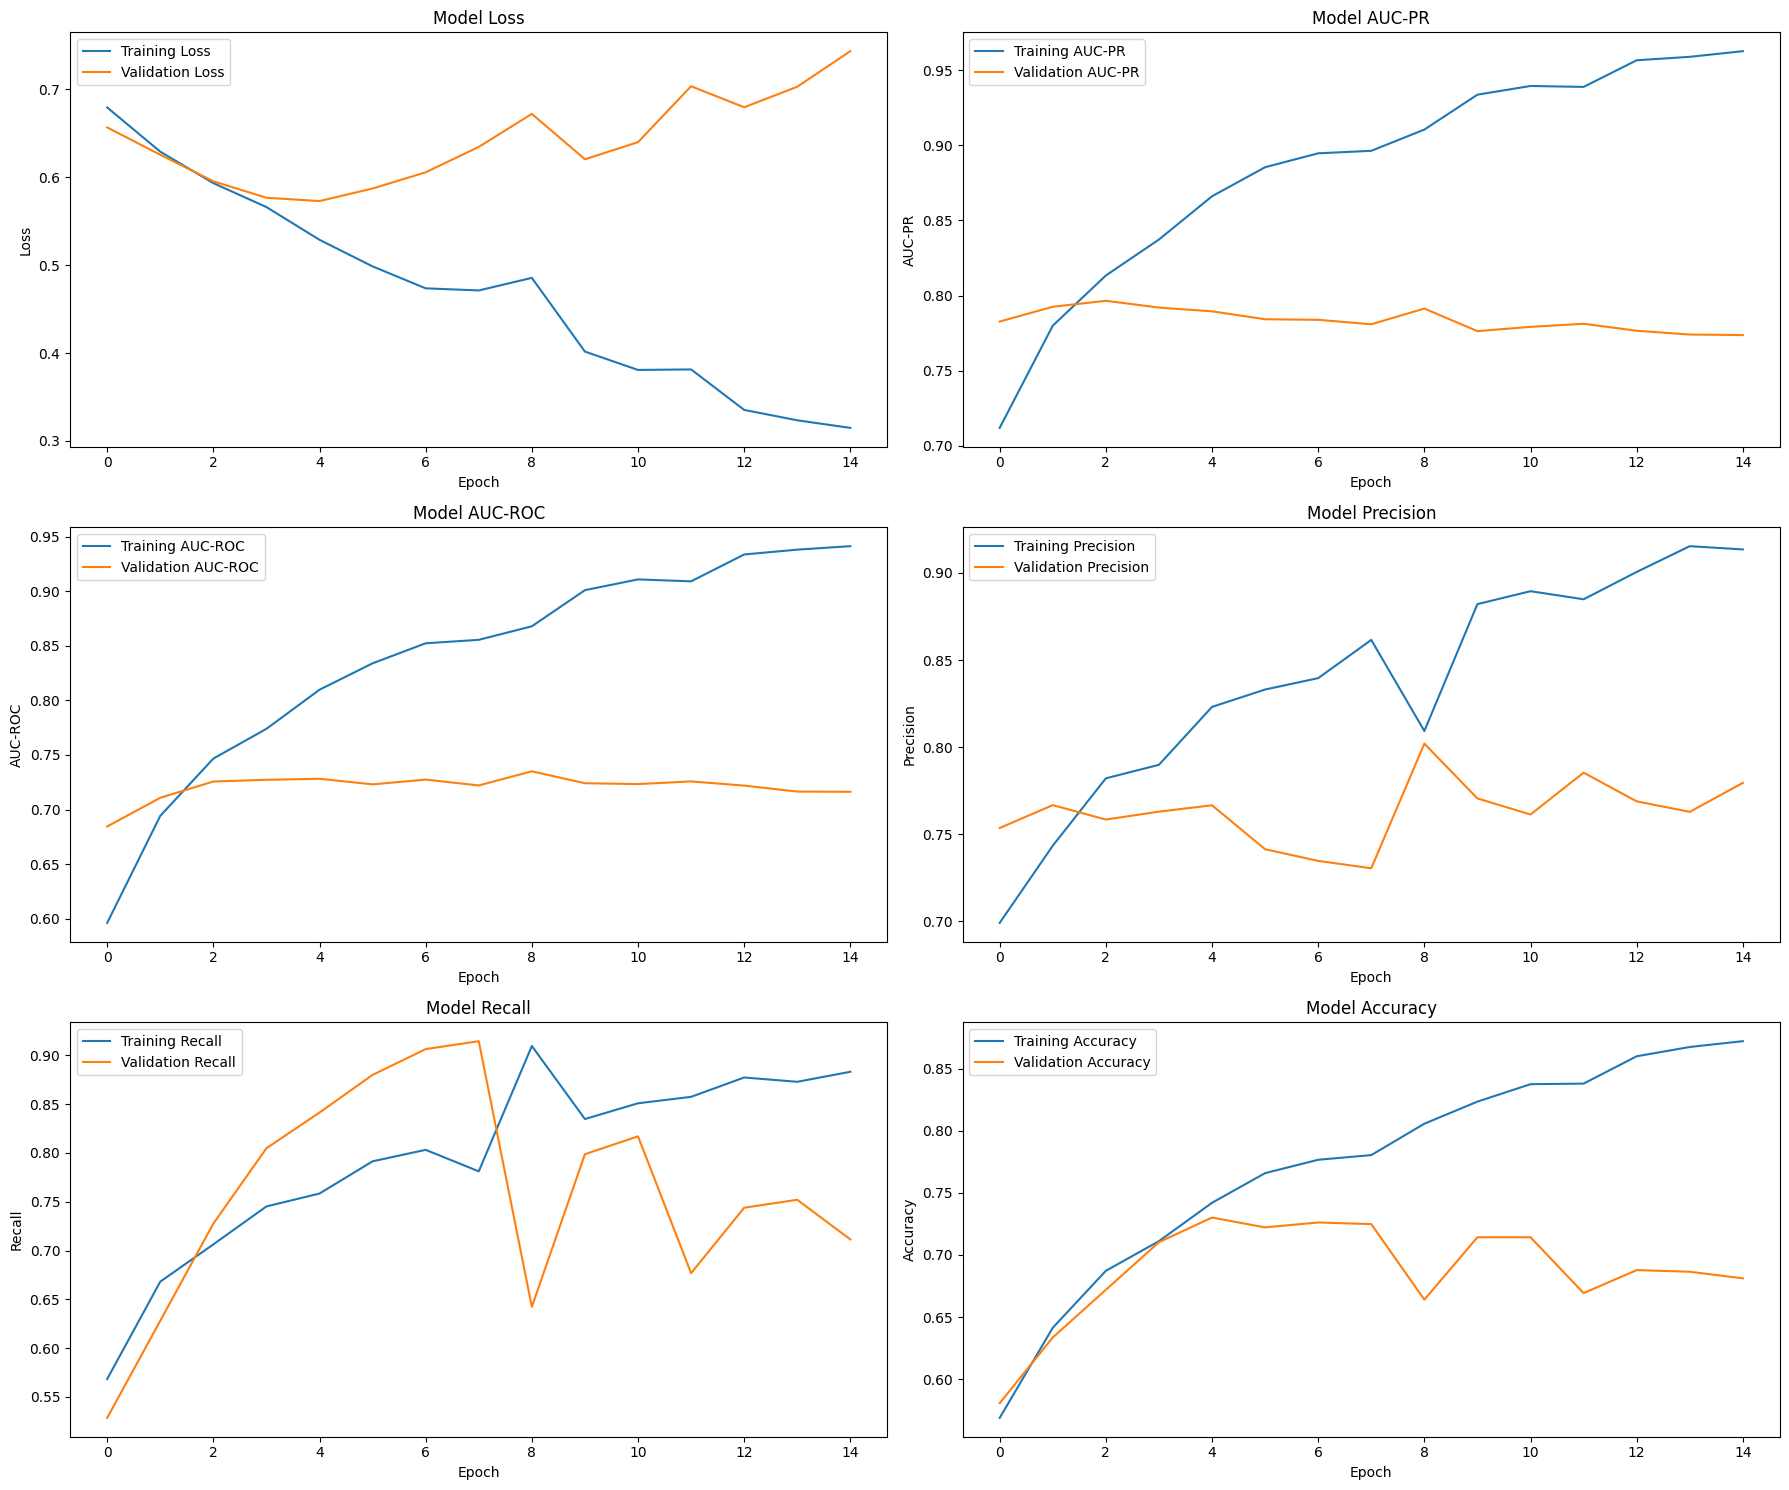

<Figure size 640x480 with 0 Axes>

In [51]:
fig, axes = plt.subplots(3, 2, figsize=(18, 15))

axes[0, 0].plot(history['loss'], label='Training Loss')
axes[0, 0].plot(history['val_loss'], label='Validation Loss')
axes[0, 0].set_title('Model Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

if 'auc_pr' in history and 'val_auc_pr' in history:
    axes[0, 1].plot(history['auc_pr'], label='Training AUC-PR')
    axes[0, 1].plot(history['val_auc_pr'], label='Validation AUC-PR')
    axes[0, 1].set_title('Model AUC-PR')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('AUC-PR')
    axes[0, 1].legend()
else:
    axes[0, 1].set_visible(False)

if 'auc_roc' in history and 'val_auc_roc' in history:
    axes[1, 0].plot(history['auc_roc'], label='Training AUC-ROC')
    axes[1, 0].plot(history['val_auc_roc'], label='Validation AUC-ROC')
    axes[1, 0].set_title('Model AUC-ROC')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('AUC-ROC')
    axes[1, 0].legend()
else:
    axes[1, 0].set_visible(False)

if 'precision' in history and 'val_precision' in history:
    axes[1, 1].plot(history['precision'], label='Training Precision')
    axes[1, 1].plot(history['val_precision'], label='Validation Precision')
    axes[1, 1].set_title('Model Precision')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Precision')
    axes[1, 1].legend()
else:
    axes[1, 1].set_visible(False)

if 'recall' in history and 'val_recall' in history:
    axes[2, 0].plot(history['recall'], label='Training Recall')
    axes[2, 0].plot(history['val_recall'], label='Validation Recall')
    axes[2, 0].set_title('Model Recall')
    axes[2, 0].set_xlabel('Epoch')
    axes[2, 0].set_ylabel('Recall')
    axes[2, 0].legend()
else:
    axes[2, 0].set_visible(False)

if 'accuracy' in history and 'val_accuracy' in history:
    axes[2, 1].plot(history['accuracy'], label='Training Accuracy')
    axes[2, 1].plot(history['val_accuracy'], label='Validation Accuracy')
    axes[2, 1].set_title('Model Accuracy')
    axes[2, 1].set_xlabel('Epoch')
    axes[2, 1].set_ylabel('Accuracy')
    axes[2, 1].legend()
else:
    axes[2, 1].set_visible(False)

plt.tight_layout()
plt.show()

# Save the main plot
plt.savefig(MODEL_RESULTS_FOLDER / f'training_history.png', dpi=300, bbox_inches='tight')

In [52]:
# Example with bilateral aggregators you already compute:
proba_val_left  = model.predict(X_val_uni_left).ravel()
proba_val_right = model.predict(X_val_uni_right).ravel()
proba_val_mean  = 0.5*(proba_val_left + proba_val_right)
proba_val_max   = np.maximum(proba_val_left, proba_val_right)

# Choose aggregator by PR-AUC on VAL (not test)
ap_mean = average_precision_score(y_val, proba_val_mean)
ap_max  = average_precision_score(y_val, proba_val_max)
use_max = ap_max >= ap_mean
val_scores = proba_val_max if use_max else proba_val_mean

best_threshold, stats = pick_threshold(y_val, val_scores, method="macro")
print( "Best aggreator:", "max" if use_max else "mean")
print( "Best by F1-Score threshold:", best_threshold, " val stats:", stats)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Best aggreator: mean
Best by F1-Score threshold: 0.305176317691803  val stats: {'macro_f1': 0.7015003948407476}


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Aggregating predictions with mean method
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Aggregating predictions with mean method
MODEL EVALUATION RESULTS
=== Test Prevalence: 61.04 ===
Test AUC-PR : 0.6780
Test AUC-ROC : 0.6334
=== Threshold Dependent Metrics ===
=== Threshold: 0.31 ===
Test Accuracy : 0.6131
Test F1-Macro Score : 0.5827
Test Precision : 0.6694
Test Recall : 0.7232

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Injured       0.67      0.72      0.70       224
 Not Injured       0.50      0.44      0.47       143

    accuracy                           0.61       367
   macro avg       0.59      0.58      0.58       367
weighted avg       0.60      0.61      0.61       367



<Figure size 640x480 with 0 Axes>

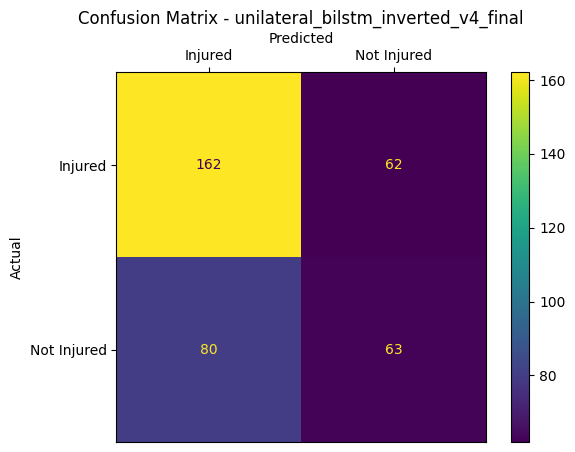

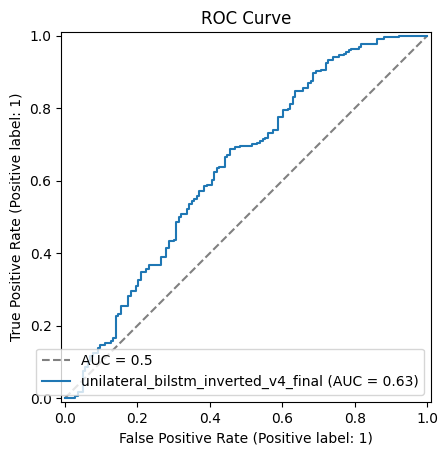

<Figure size 640x480 with 0 Axes>

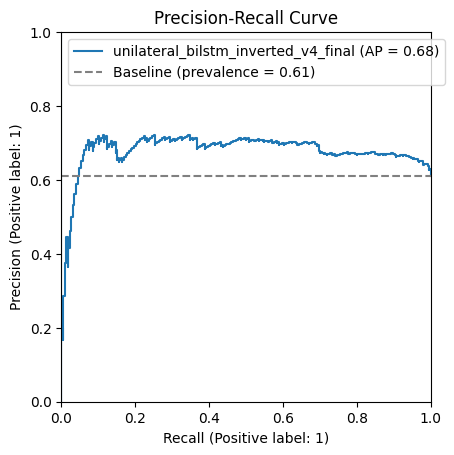

In [53]:
best_aggregator = "max" if use_max else "mean"
pred = UnilateralPredictor(model, aggregation=best_aggregator, verbose=True)
test_summary = model_test_summary(model, [X_test_uni_left, X_test_uni_right], y_test, threshold=best_threshold, predictor=pred)

In [54]:
# Save the trained model
if SAVE_MODEL:
    model_loader.save_keras_model_to_disk()
    
    # Save scalers for future use
    scalers = {
        'timeseries_scaler': scaler_ts,
    }
    model_loader.save_scalers_to_disk(scalers)

    # Save training results
    results = {
        'test_accuracy': float(test_summary['accuracy']),
        'test_f1': float(test_summary['f1']),
        'tes_avg_precision': float(test_summary['auc_pr']),
        'test_auc_roc': float(test_summary['auc_roc']),
        'test_precision': float(test_summary['precision']),
        'test_recall': float(test_summary['recall']),   
        'test_prevalence': float(test_summary['prevalence']),
        'threshold': float(test_summary['threshold']),
        'model_name': MODEL_NAME,
        'training_params': {
            "epochs": model.history.params['epochs'],
            'epochs_run': len(model.history.epoch),
            'history': model.history.history,
            'batch_size': BATCH_SIZE,
            'learning_rate': float(model.optimizer.learning_rate.numpy()),
            'dropout_rate': next((layer.rate for layer in model.layers if hasattr(layer, 'rate')), "N/A"),
            'class_weights': class_weight_dict
        }
    }
    model_loader.save_results_to_disk(results)

    print(f"Model and results saved!")

## Model Explainability

Let's analyze feature importance using gradient-based saliency maps to understand which features and time points are most important for the model's predictions.


In [55]:
from core.evaluation import (
    compute_timeseries_saliency,
    plot_timeseries_saliency,
    analyze_sample_saliency,
    get_unilateral_feature_names
)

Left Side Analysis
Analyzing injured sample (index 0) and healthy sample (index 5)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Model predictions:
  Injured sample (true=1): 0.5129
  Healthy sample (true=0): 0.8203

Plotting saliency for injured sample...


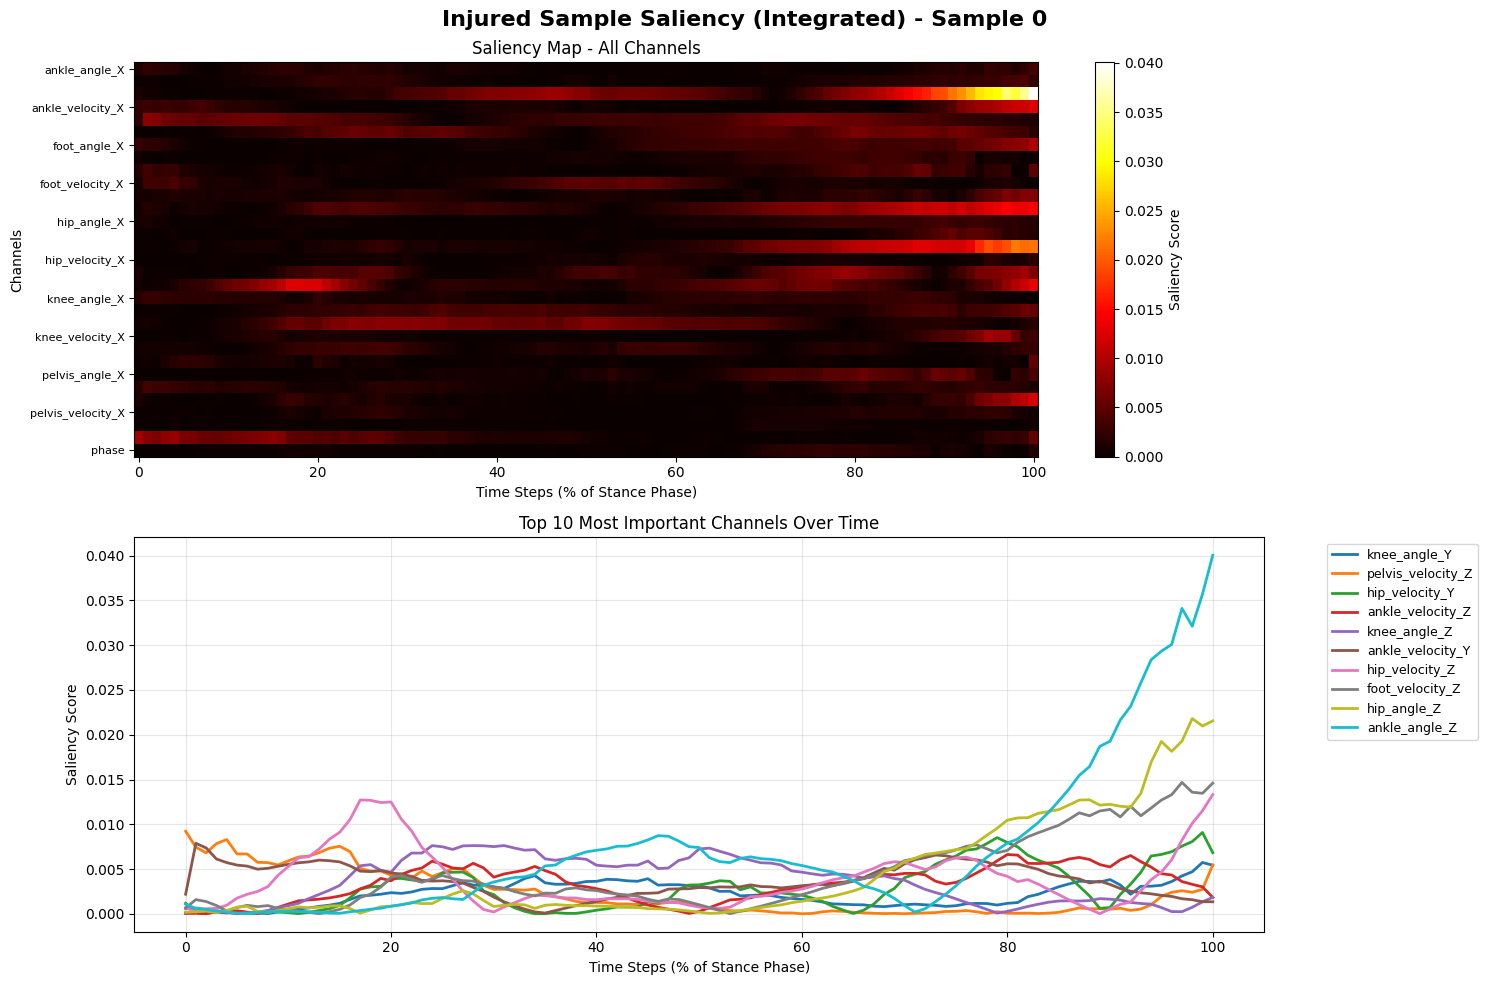


Plotting saliency for healthy sample...


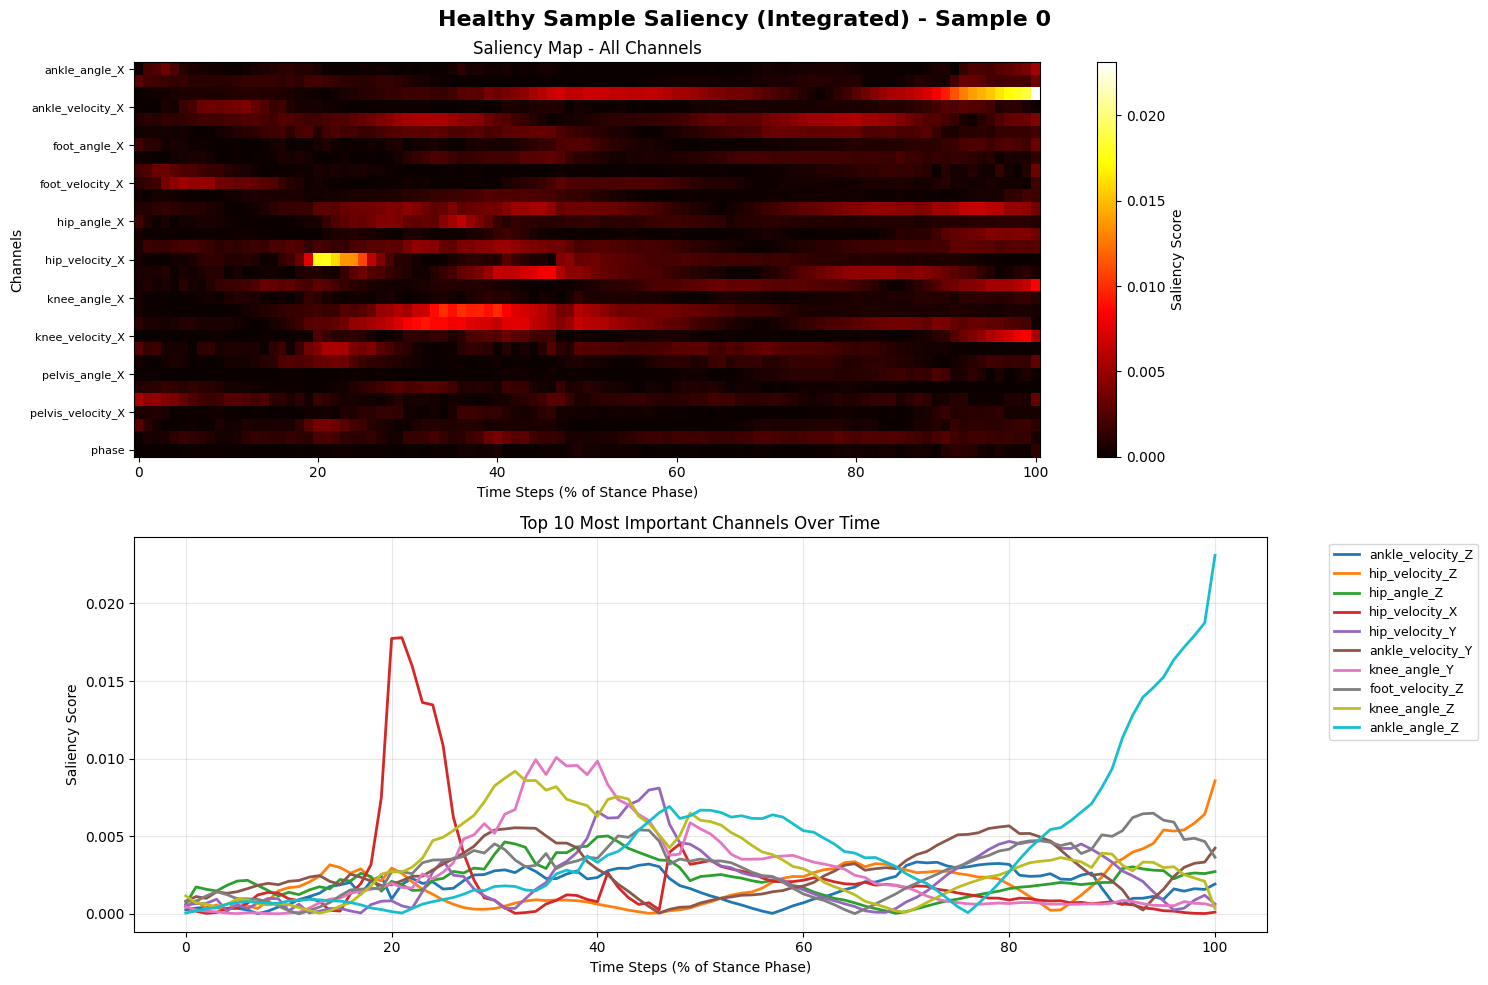


Top 5 features for injured sample:
  1. ankle_angle_Z: 0.0072
  2. hip_angle_Z: 0.0045
  3. foot_velocity_Z: 0.0045
  4. hip_velocity_Z: 0.0039
  5. ankle_velocity_Y: 0.0037

Top 5 features for healthy sample:
  1. ankle_angle_Z: 0.0043
  2. knee_angle_Z: 0.0034
  3. foot_velocity_Z: 0.0030
  4. knee_angle_Y: 0.0028
  5. ankle_velocity_Y: 0.0028
Right Side Analysis
Analyzing injured sample (index 0) and healthy sample (index 5)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Model predictions:
  Injured sample (true=1): 0.4902
  Healthy sample (true=0): 0.8637

Plotting saliency for injured sample...


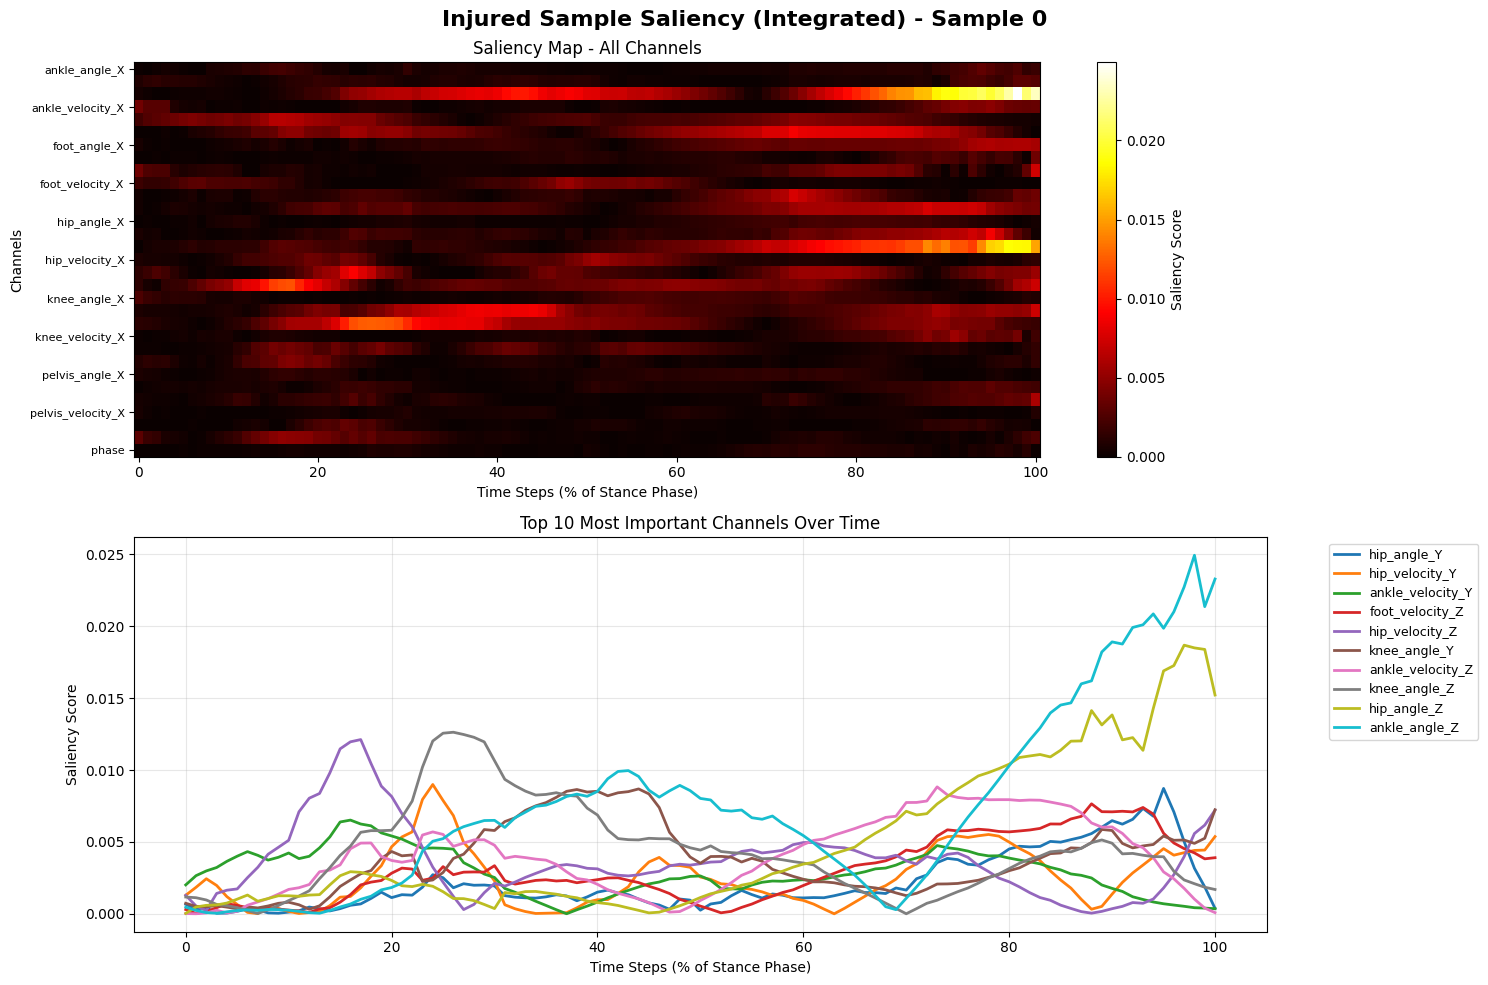


Plotting saliency for healthy sample...


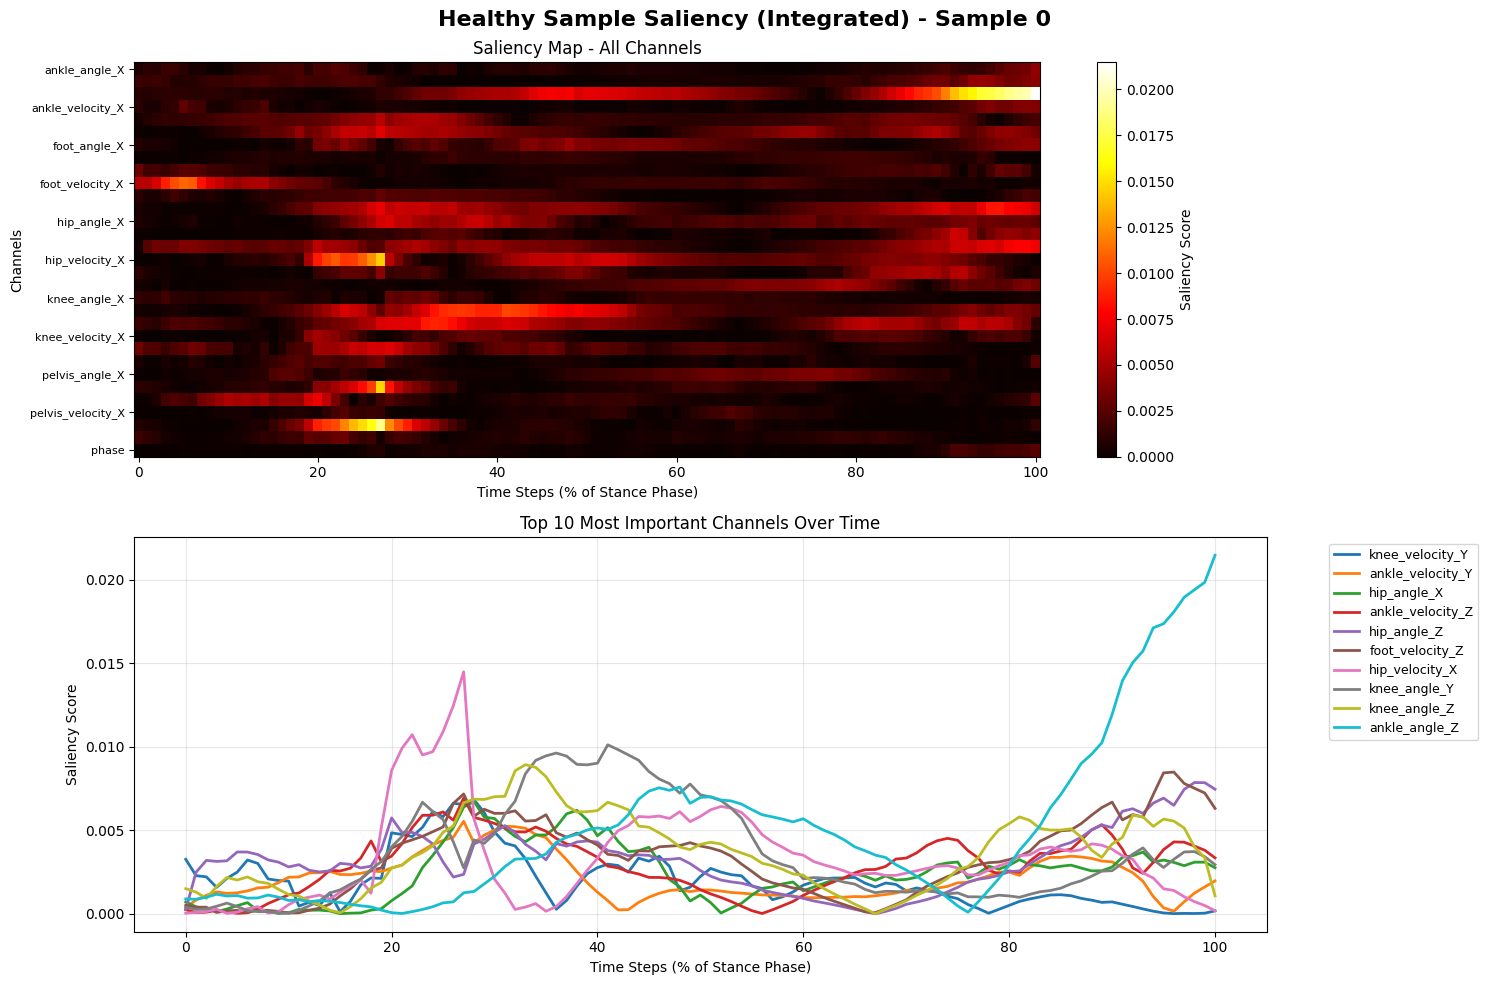


Top 5 features for injured sample:
  1. ankle_angle_Z: 0.0073
  2. hip_angle_Z: 0.0050
  3. knee_angle_Z: 0.0043
  4. ankle_velocity_Z: 0.0040
  5. knee_angle_Y: 0.0038

Top 5 features for healthy sample:
  1. ankle_angle_Z: 0.0050
  2. knee_angle_Z: 0.0037
  3. knee_angle_Y: 0.0036
  4. hip_velocity_X: 0.0034
  5. foot_velocity_Z: 0.0034


In [56]:
print("Left Side Analysis")
print("="*50)
l_feature_names = get_unilateral_feature_names(channels, side="L")
l_saliency = compute_timeseries_saliency(model, X_test_uni_left, method="vanilla")
l_results = analyze_sample_saliency(model, X_test_uni_left, y_test, l_feature_names)

print("Right Side Analysis")
print("="*50)
r_feature_names = get_unilateral_feature_names(channels, side="R")
r_saliency = compute_timeseries_saliency(model, X_test_uni_right, method="vanilla")
r_results = analyze_sample_saliency(model, X_test_uni_right, y_test, r_feature_names)